<a href="https://colab.research.google.com/github/MalavMDesai/GenAIAssignment/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!apt-get install -y graphviz
!pip install keras-visualizer
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from keras_visualizer import visualizer
from IPython.display import Image
import os

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 67 not upgraded.


In [8]:
url="https://github.com/MalavMDesai/GenAIAssignment/raw/refs/heads/main/assignment3.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
le = LabelEncoder()
df['MerchantCategory'] = le.fit_transform(df['MerchantCategory'])
df

,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,AccountBalance,NumberOfTransactionsToday,Fraud
0,72.03,14,4,30,11311.70,8,0
1,71.42,6,0,63,9661.54,8,0
2,93.41,4,1,56,7134.03,2,0
3,12.24,8,2,33,6993.46,4,0
4,666.71,14,4,27,9272.85,1,1
...,...,...,...,...,...,...,...
95,268.89,12,3,42,5683.84,1,0
96,168.44,23,0,27,9684.62,7,0
97,86.16,19,4,20,9511.97,8,0
98,170.74,5,0,53,4092.93,3,1


In [9]:
features = df.drop(columns=['Fraud'])
target = df['Fraud']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_train, features_test, target_train, target_test = train_test_split(
    features_scaled,
    target,
    test_size=0.2,
    random_state=827
)


In [10]:
model = Sequential()
model.add(Dense(units=5, input_shape=(6,), activation='relu', name='Hidden_Layer'))
model.add(Dense(units=5, input_shape=(5,), activation='relu', name='Hidden_layer'))
model.add(Dense(units=1, activation='sigmoid', name='Output_Layer'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer (Dense)            │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71 (284.00 B)

 Trainable params: 71 (284.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    features_train,
    target_train,
    epochs=50,
    validation_split=0.1,
    batch_size=8,
    verbose=0
)

test_loss, test_acc = model.evaluate(features_test, target_test)
print(f"test loss: {test_loss}")
print(f"test accuracy: {test_acc}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9500 - loss: 0.1921
test loss: 0.19211287796497345
test accuracy: 0.949999988079071


Done
186435


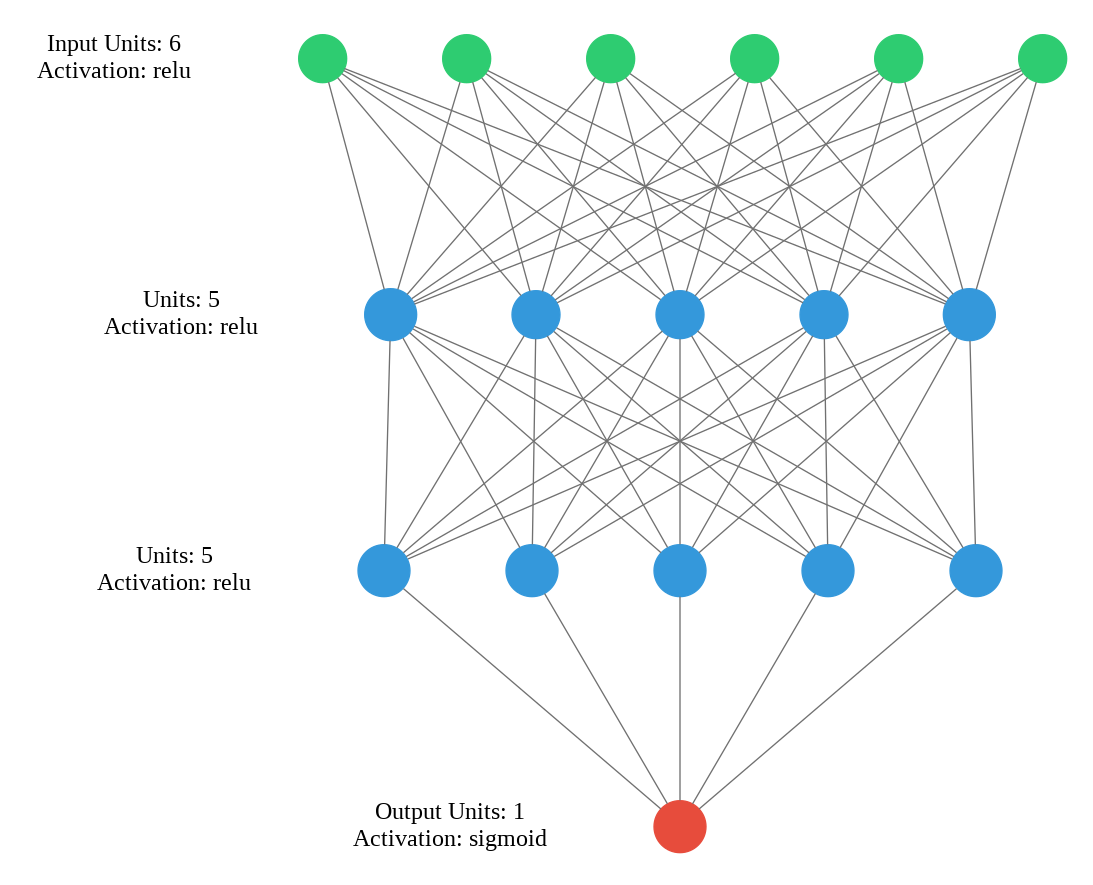

In [12]:
try:
    visualizer(
        model,
        "graph",
        file_format='png'
    )
    print("Done")
except Exception as e:
    print(type(e).__name__)
    print(e)

print(os.path.getsize("graph.png"))
Image('graph.png')
